In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 23.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 31.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 44.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
!pip install python-bcb



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 18.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 39.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 43.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [python-bcb]4 [python-bcb]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Dados coletados: 85 observações
Período: 2019-01-01 00:00:00 a 2026-01-01 00:00:00
Inadimplência atual: 4.25%


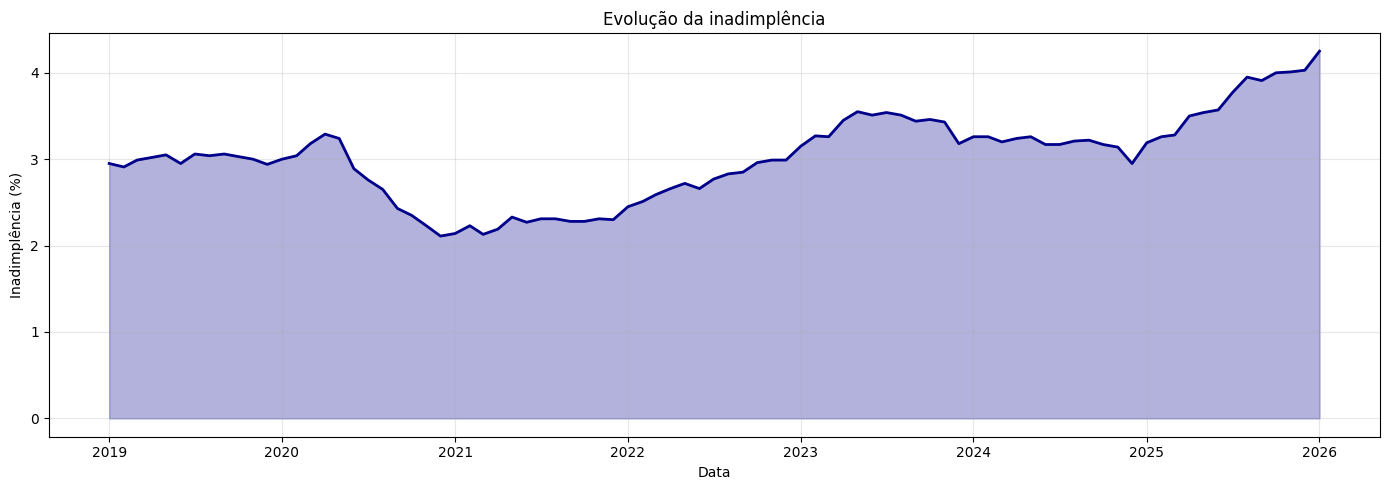

,data,inad_total
80,2025-09-01,3.91
81,2025-10-01,4.00
82,2025-11-01,4.01
83,2025-12-01,4.03
84,2026-01-01,4.25


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from bcb import sgs
import warnings
warnings.filterwarnings('ignore')

# Série-alvo
inad_total = sgs.get({"inad_total": 21082}, start="2019-01-01")
inad_total = inad_total.reset_index()
inad_total.columns = ["data", "inad_total"]
inad_total["data"] = pd.to_datetime(inad_total["data"])

print(f"Dados coletados: {len(inad_total)} observações")
print(f"Período: {inad_total['data'].min()} a {inad_total['data'].max()}")
print(f"Inadimplência atual: {inad_total['inad_total'].iloc[-1]:.2f}%")

plt.figure(figsize=(14, 5))
plt.plot(inad_total["data"], inad_total["inad_total"], linewidth=2, color="darkblue")
plt.fill_between(inad_total["data"], inad_total["inad_total"], alpha=0.3, color="darkblue")
plt.xlabel("Data")
plt.ylabel("Inadimplência (%)")
plt.title("Evolução da inadimplência")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

inad_total.tail()

In [7]:
DATA_INICIO = "2019-01-01"

# Série-alvo + exógenas mensais
df_base = sgs.get({
    "inad_total": 21082,
    "saldo_total": 20539,
    "concessao_total": 20631,
    "juros_total": 20714,
    "ipca": 433
}, start=DATA_INICIO)

# Selic diária
df_selic = sgs.get({"selic": 432}, start=DATA_INICIO)

# Ajustar índice de datas
df_base.index = pd.to_datetime(df_base.index)
df_selic.index = pd.to_datetime(df_selic.index)

# Transformar Selic diária em mensal
df_selic_mensal = df_selic.resample("MS").mean()

# Juntar tudo
df_modelo = df_base.join(df_selic_mensal, how="left")

# Resetar índice
df_modelo = df_modelo.reset_index().rename(columns={"index": "data"})
df_modelo = df_modelo.rename(columns={"Date": "data"})

# Garantir nome da coluna de data
if "data" not in df_modelo.columns:
    df_modelo = df_modelo.rename(columns={df_modelo.columns[0]: "data"})

# Ordenar por data
df_modelo = df_modelo.sort_values("data").reset_index(drop=True)

print(df_modelo.head())
print(df_modelo.tail())
print(df_modelo.info())

        data  inad_total  saldo_total  concessao_total  juros_total  ipca  \
0 2019-01-01        2.95    3237076.0         284019.0        24.46  0.32   
1 2019-02-01        2.91    3247396.0         284219.0        24.79  0.43   
2 2019-03-01        2.99    3273000.0         297678.0        25.07  0.75   
3 2019-04-01        3.02    3272570.0         304796.0        25.13  0.57   
4 2019-05-01        3.05    3291212.0         329959.0        24.96  0.13   

   selic  
0    6.5  
1    6.5  
2    6.5  
3    6.5  
4    6.5  
         data  inad_total  saldo_total  concessao_total  juros_total  ipca  \
81 2025-10-01        4.00    6919371.0         690692.0        31.89  0.09   
82 2025-11-01        4.01    6999002.0         651192.0        32.38  0.18   
83 2025-12-01        4.03    7130222.0         802912.0        32.06  0.33   
84 2026-01-01        4.25    7115576.0         651453.0        32.76  0.33   
85 2026-02-01         NaN          NaN              NaN          NaN  0.70   

  

In [8]:
df_alvo = df_modelo[["data", "inad_total"]].copy()

df_exogenas = df_modelo[[
    "data",
    "saldo_total",
    "concessao_total",
    "juros_total",
    "selic",
    "ipca"
]].copy()

In [19]:
# Garantir formato de data
df_modelo["data"] = pd.to_datetime(df_modelo["data"])

# Aplicar data de corte
df_modelo = df_modelo[df_modelo["data"] <= "2025-12-31"].copy()

# Remover valores faltantes
df_modelo = df_modelo.dropna().reset_index(drop=True)

print(f"Período final da base: {df_modelo['data'].min().date()} até {df_modelo['data'].max().date()}")
print(f"Número de observações: {len(df_modelo)}")

# Cópia da base para o EDA
df_eda = df_modelo.copy()

# Garantir formato de data
df_eda["data"] = pd.to_datetime(df_eda["data"])

# Ordenar por data
df_eda = df_eda.sort_values("data").reset_index(drop=True)

# Variáveis de interesse
colunas_analise = [
    "inad_total",
    "saldo_total",
    "concessao_total",
    "juros_total",
    "selic",
    "ipca"
]

df_eda.head()

Período final da base: 2019-01-01 até 2025-12-01
Número de observações: 84


,data,inad_total,saldo_total,concessao_total,juros_total,ipca,selic
0,2019-01-01,2.95,3237076.0,284019.0,24.46,0.32,6.5
1,2019-02-01,2.91,3247396.0,284219.0,24.79,0.43,6.5
2,2019-03-01,2.99,3273000.0,297678.0,25.07,0.75,6.5
3,2019-04-01,3.02,3272570.0,304796.0,25.13,0.57,6.5
4,2019-05-01,3.05,3291212.0,329959.0,24.96,0.13,6.5


In [20]:
print("=== VISÃO GERAL DA BASE ===")
print(f"Número de linhas: {df_eda.shape[0]}")
print(f"Número de colunas: {df_eda.shape[1]}")
print(f"Período da base: {df_eda['data'].min().date()} até {df_eda['data'].max().date()}")

print("\n=== TIPOS DAS VARIÁVEIS ===")
print(df_eda.dtypes)

print("\n=== VALORES FALTANTES ===")
faltantes = df_eda[colunas_analise].isna().sum().to_frame("qtd_faltantes")
faltantes["pct_faltantes"] = (faltantes["qtd_faltantes"] / len(df_eda) * 100).round(2)
print(faltantes)

print("\n=== PRIMEIRAS LINHAS ===")
print(df_eda.head())

print("\n=== ÚLTIMAS LINHAS ===")
print(df_eda.tail())

=== VISÃO GERAL DA BASE ===
Número de linhas: 84
Número de colunas: 7
Período da base: 2019-01-01 até 2025-12-01

=== TIPOS DAS VARIÁVEIS ===
data               datetime64[us]
inad_total                float64
saldo_total               float64
concessao_total           float64
juros_total               float64
ipca                      float64
selic                     float64
dtype: object

=== VALORES FALTANTES ===
                 qtd_faltantes  pct_faltantes
inad_total                   0            0.0
saldo_total                  0            0.0
concessao_total              0            0.0
juros_total                  0            0.0
selic                        0            0.0
ipca                         0            0.0

=== PRIMEIRAS LINHAS ===
        data  inad_total  saldo_total  concessao_total  juros_total  ipca  \
0 2019-01-01        2.95    3237076.0         284019.0        24.46  0.32   
1 2019-02-01        2.91    3247396.0         284219.0        24.79  0.43   


In [12]:
estatisticas = df_eda[colunas_analise].describe().T

estatisticas["mediana"] = df_eda[colunas_analise].median()
estatisticas["amplitude"] = estatisticas["max"] - estatisticas["min"]
estatisticas["coef_variacao"] = (estatisticas["std"] / estatisticas["mean"]).round(4)

print("=== ESTATÍSTICAS DESCRITIVAS ===")
print(estatisticas[[
    "count", "mean", "mediana", "std", "min", "max", "amplitude", "coef_variacao"
]].round(4))

=== ESTATÍSTICAS DESCRITIVAS ===
                 count          mean       mediana           std         min  \
inad_total        85.0  3.017500e+00  3.040000e+00  4.992000e-01        2.11   
saldo_total       85.0  4.977125e+06  4.997242e+06  1.199132e+06  3237076.00   
concessao_total   85.0  4.807947e+05  5.004000e+05  1.263600e+05   284019.00   
juros_total       85.0  2.624240e+01  2.759000e+01  4.333800e+00       17.95   
selic             86.0  9.368400e+00  1.069640e+01  4.519000e+00        2.00   
ipca              86.0  4.470000e-01  4.150000e-01  4.113000e-01       -0.68   

                        max   amplitude  coef_variacao  
inad_total             4.25        2.14         0.1654  
saldo_total      7130222.00  3893146.00         0.2409  
concessao_total   802912.00   518893.00         0.2628  
juros_total           32.76       14.81         0.1651  
selic                 15.00       13.00         0.4824  
ipca                   1.62        2.30         0.9202  


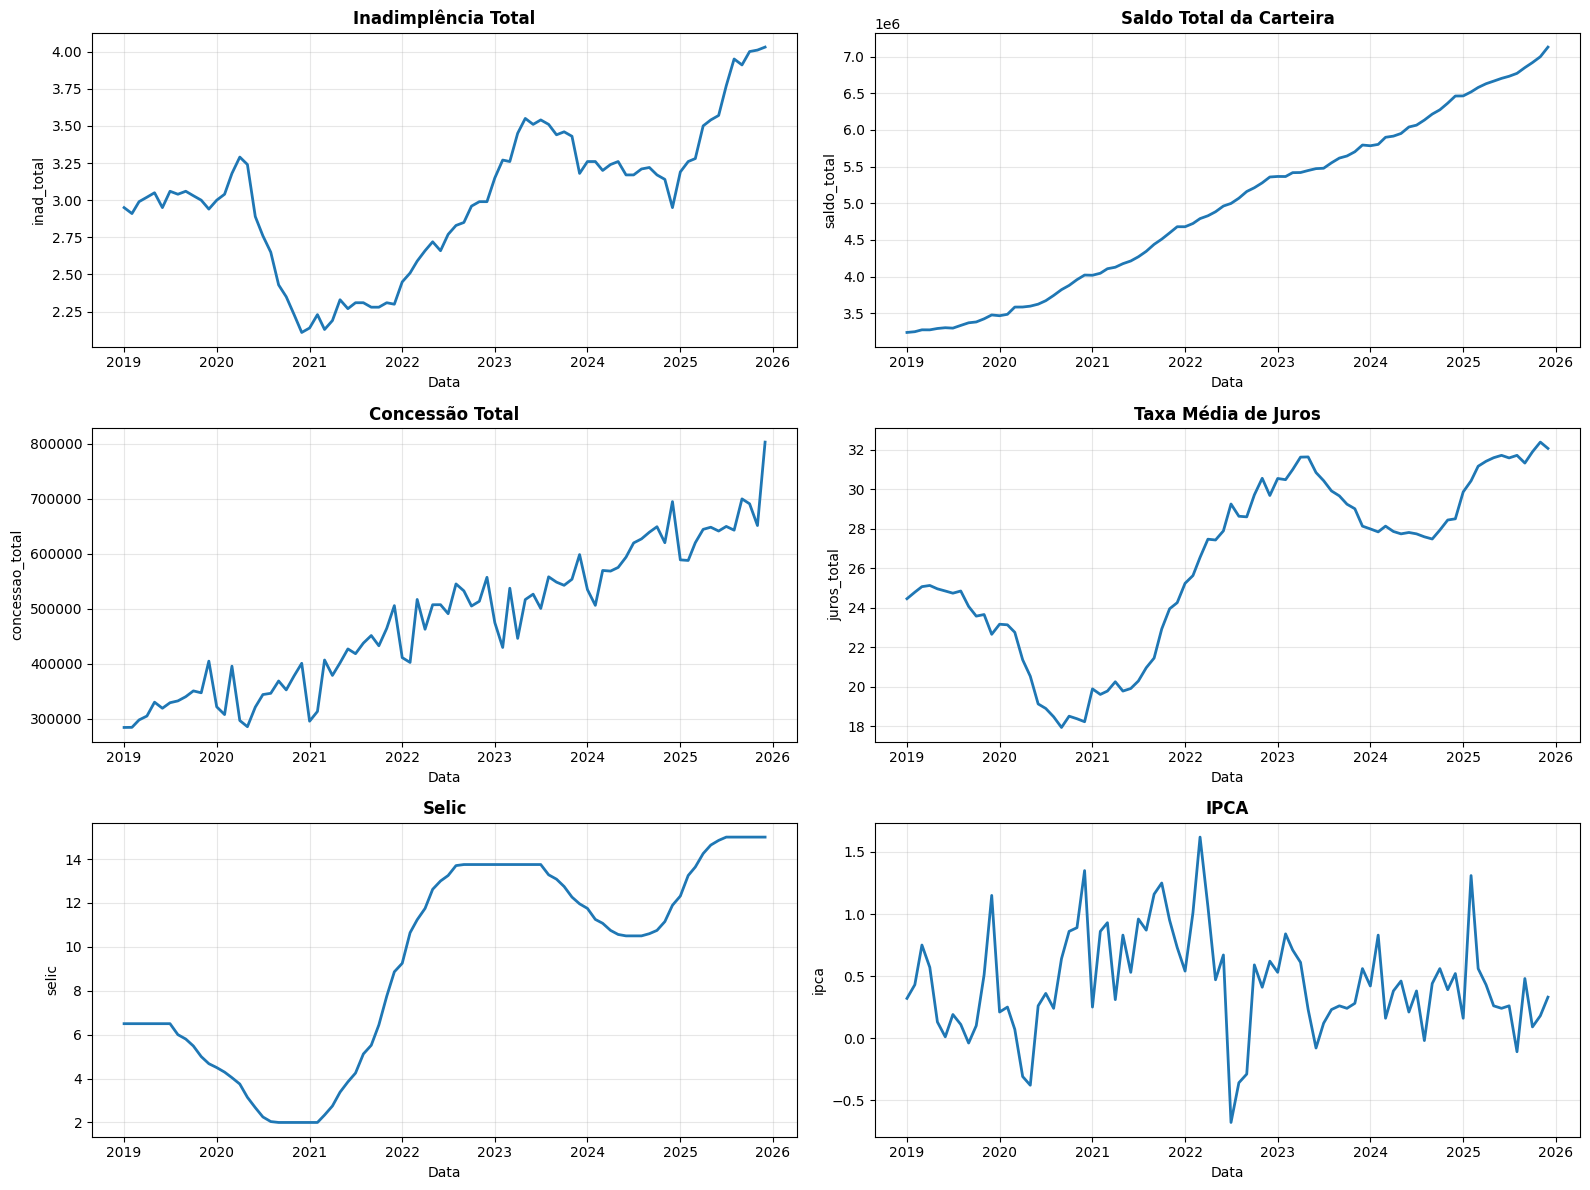

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

titulos = {
    "inad_total": "Inadimplência Total",
    "saldo_total": "Saldo Total da Carteira",
    "concessao_total": "Concessão Total",
    "juros_total": "Taxa Média de Juros",
    "selic": "Selic",
    "ipca": "IPCA"
}

for i, coluna in enumerate(colunas_analise):
    axes[i].plot(df_eda["data"], df_eda[coluna], linewidth=2)
    axes[i].set_title(titulos[coluna], fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Data")
    axes[i].set_ylabel(coluna)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
correlacao_simples = df_eda[colunas_analise].corr()

print("=== CORRELAÇÃO SEM DEFASAGEM ===")
print(correlacao_simples["inad_total"].sort_values(ascending=False).round(4))

=== CORRELAÇÃO SEM DEFASAGEM ===
inad_total         1.0000
juros_total        0.7845
selic              0.6933
saldo_total        0.6148
concessao_total    0.5794
ipca              -0.4706
Name: inad_total, dtype: float64


In [24]:
variaveis_exogenas = [
    "saldo_total",
    "concessao_total",
    "juros_total",
    "selic",
    "ipca"
]

lags = [0, 3, 6]

resultados_correlacao = []

for var in variaveis_exogenas:
    for lag in lags:
        correlacao = df_eda["inad_total"].corr(df_eda[var].shift(lag))
        resultados_correlacao.append({
            "variavel": var,
            "lag": lag,
            "correlacao_com_inad_total": correlacao
        })

df_correlacoes = pd.DataFrame(resultados_correlacao)
df_correlacoes["correlacao_com_inad_total"] = df_correlacoes["correlacao_com_inad_total"].round(4)

print("=== CORRELAÇÕES DE INADIMPLÊNCIA COM DEFASAGENS ===")
print(df_correlacoes)

=== CORRELAÇÕES DE INADIMPLÊNCIA COM DEFASAGENS ===
           variavel  lag  correlacao_com_inad_total
0       saldo_total    0                     0.6148
1       saldo_total    3                     0.6547
2       saldo_total    6                     0.7048
3   concessao_total    0                     0.5794
4   concessao_total    3                     0.6132
5   concessao_total    6                     0.6830
6       juros_total    0                     0.7845
7       juros_total    3                     0.8954
8       juros_total    6                     0.9203
9             selic    0                     0.6933
10            selic    3                     0.8054
11            selic    6                     0.8602
12             ipca    0                    -0.4706
13             ipca    3                    -0.3112
14             ipca    6                    -0.1456


In [25]:
df_modelo.to_csv("base_series.csv")